# EDA - données de trafic routier

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from tqdm import tqdm
from predictions_fortes_concentrations.paths.paths import path_to_trafic_data

# Read data

## Lire le parquet contenant toutes les données

In [ ]:
path_to_trafic_data = Path(path_to_trafic_data)

dtype_map = {
    "iu_ac": "int32",
    "iu_nd_amont": "int32",
    "iu_nd_aval": "int32",
    "etat_trafic": "int8",
    "etat_barre": "int8",
    "q": "float32",
    "k": "float32",
    "libelle": "category"
}

trafic_df = pd.read_parquet(
    path_to_trafic_data + "\all_traffic_data_grand_paris_sans_na.parquet",
    columns=["iu_ac","libelle","iu_nd_amont","iu_nd_aval","t_1h","q","k","etat_trafic","etat_barre"]
).astype(dtype_map)

trafic_df["t_1h"] = pd.to_datetime(trafic_df["t_1h"])

# Preprocessing

In [ ]:
trafic_df.rename(
    columns={
        "q":"debit",
        "k":"taux_occup",
        "t_1h":"date_fin",
        "etat_trafic":"etat_trafic_encode",
        "etat_barre":"etat_barre_encode",
        "libelle":"voie"
    },
    inplace=True
)

trafic_df.drop_duplicates(
    subset=["iu_ac", "date_fin"],
    keep='first',
    inplace=True
)

mapping_etat_trafic = {
        0:"inconnu",
        1:"fluide",
        2:"pre-sature",
        3:"sature",
        4:"bloque"
    }
mapping_etat_barre = {
        0:"inconnu",
        1:"ouvert",
        2:"barre",
        3:"invalide",
    }

mapping_jour_semaine = {
    0: "lundi",
    1: "mardi",
    2: "mercredi",
    3: "jeudi",
    4: "vendredi",
    5: "samedi",
    6: "dimanche"
}

## Missing Values

Pour des raisons de RAM, j'ai exporté tous les fichiers de 2021 à 2023 dans un parquet sans les valeurs manqantes. Le DataFrame analysé dans ce notebook ne contient donc pas de valeurs manquantes.
Cependant, on a des taux de 50% de valeurs manquantes sur le débit et le taux d'occupation. 

Aucun pattern spécifique ne se dégage de ces valeurs manquantes, elles concernent tous les arcs, sur toute la période et à toutes les heures de la journée. 
Elles proviennent probablement de problèmes techniques liés à des pannes, maintenances ou données non remontées. Pour cette raison, il n'est pas possible d'imputer simplement les valeurs manquantes.
Il existe 2 solutions pour notre projet :

1- Les ignorer : considérant le fait que nos zones sont définies par les capteurs de concentration en polluant et qu'il y a plusieurs stations de comptage par zone (à vérifier pour toutes les stations), on peut raisonnablement penser que, à chaque moment de la journée, au moins une station de comptage sera active par zone

2- Imputer : pour une station de comptage inactive durant une certaine période, prendre les valeurs de trafic de la station de comptage active la plus proche sur cette même période

La solution finale réside probablement dans un mix des deux : 
- s'il existe au moins une station de comptage actif dans la zone, prendre les valeurs de celle-ci pour la zone
- sinon, imputer toutes les stations de comptage inactive de la zone

Dans la suite de cette EDA, les valeurs manquantes sont ignorées pour ne pas fausser l'analyse

In [22]:
trafic_df.isna().mean()

iu_ac                 0.0
voie                  0.0
iu_nd_amont           0.0
iu_nd_aval            0.0
date_fin              0.0
debit                 0.0
taux_occup            0.0
etat_trafic_encode    0.0
etat_barre_encode     0.0
dtype: float64

## Outliers

La seule colonne pour laquelle on pourrait avoir des outliers est débit. En effet, un taux d'occupation peut raisonnablement prendre toutes les valeurs entre 0 et 100% et les aures variables sont catégorielles ou des ids.
Concernant débit, on a clairement certaines valeurs aberrantes (un max à ~32000 véhicules par heure par exemple). Il faut donc définir un seuil au-delà duquel on considère qu'une mesure est une erreur technique. 
Il est assez difficile de trouver de la documentation à ce sujet. Néanmoins, en observant la distribution de la variable débit sur les hautes valeurs, on remarque une chute du nombre d'occurrences à partir de 9000 véhicules par heure : c'est cette valeur qui est choisie comme seuil. On peut cependant être critique vis-à-vis de ce choix : 9000 véhicules par heure c'est 2.5 véhicules toutes les secondes ce qui paraît conséquent, même sur une multi-voies

In [61]:
trafic_df.query("debit < 9000", inplace=True)

# EDA

In [84]:
date_min = trafic_df["date_fin"].min()
date_max = trafic_df["date_fin"].max()
nb_arc = trafic_df["iu_ac"].nunique()
unique_amont = trafic_df["iu_nd_amont"].dropna().unique()
unique_aval  = trafic_df["iu_nd_aval"].dropna().unique()
nb_noeud = len(np.union1d(unique_amont, unique_aval))
nb_voie = trafic_df["voie"].nunique()

valeurs_encode_etat_trafic = trafic_df["etat_trafic_encode"].unique().tolist()
valeurs_etat_trafic = [mapping_etat_trafic[v] for v in valeurs_encode_etat_trafic]

valeurs_encode_etat_barre = trafic_df["etat_barre_encode"].unique().tolist()
valeurs_etat_barre = [mapping_etat_barre[v] for v in valeurs_encode_etat_barre]

max_debit = trafic_df["debit"].max()
min_debit = trafic_df["debit"].min()
max_taux_occup = trafic_df["taux_occup"].max()
min_taux_occup = trafic_df["taux_occup"].min()

print(f'Shape du DF : {trafic_df.shape}')
print(f'les observatons von du {date_min} au {date_max}')
print(f'Nombre d arcs distincts : {nb_arc}')
print(f'Nombre de noeuds distincts : {nb_noeud}')
print(f'Nombre de voies distinctes : {nb_voie}')
print(f'Catégories de l état du trafic : {valeurs_etat_trafic}')
print(f'Catégories de l état de la section : {valeurs_etat_barre}')
print(f'Le débit va de {min_debit} voitures par heure à {max_debit} voitures par heure')
print(f'Le taux d occupation va de {min_taux_occup}% à {max_taux_occup}%')

Shape du DF : (31843729, 9)
les observatons von du 2021-01-01 01:00:00 au 2024-01-01 00:00:00
Nombre d arcs distincts : 1739
Nombre de noeuds distincts : 1380
Nombre de voies distinctes : 528
Catégories de l état du trafic : ['fluide', 'pre-sature', 'sature', 'bloque']
Catégories de l état de la section : ['invalide', 'ouvert', 'barre']
Le débit va de 0.0 voitures par heure à 8946.0 voitures par heure
Le taux d occupation va de 0.0% à 100.0%


## Distribution des variables principales

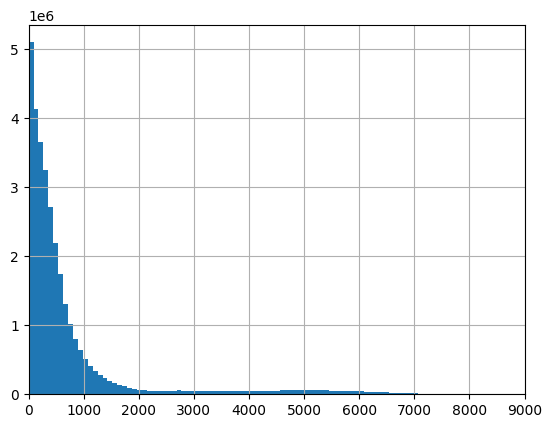

In [63]:
hist_debit = trafic_df["debit"].hist(bins=100)
hist_debit.set_xlim(0, 9000)
plt.show()

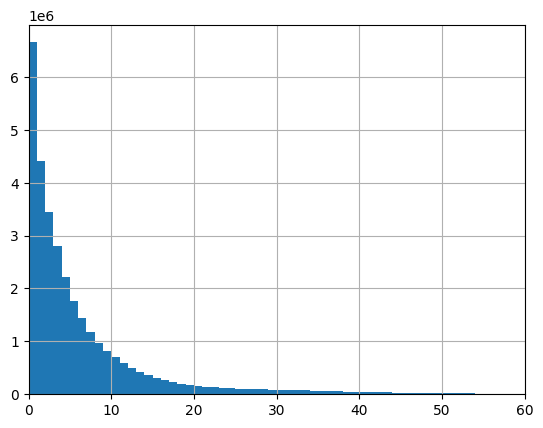

In [64]:
hist_taux_occup = trafic_df["taux_occup"].hist(bins=100)
hist_taux_occup.set_xlim(0, 60)
plt.show()

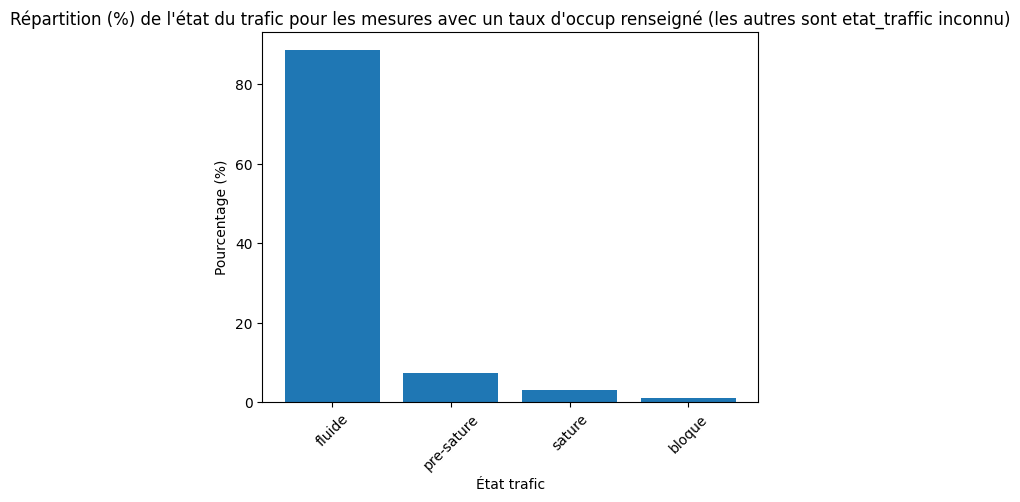

In [65]:
distrib_etat_trafic = trafic_df["etat_trafic_encode"].value_counts(normalize=True) * 100
labels = distrib_etat_trafic.index.map(mapping_etat_trafic)

plt.figure()
plt.bar(labels, distrib_etat_trafic.values)
plt.xlabel("État trafic")
plt.ylabel("Pourcentage (%)")
plt.title("Répartition (%) de l'état du trafic pour les mesures avec un taux d'occup renseigné (les autres sont etat_traffic inconnu)")
plt.xticks(rotation=45)
plt.show()

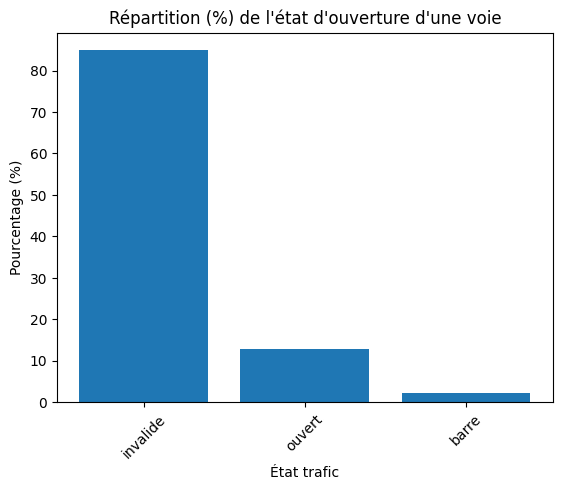

In [66]:
distrib_etat_barre = trafic_df["etat_barre_encode"].value_counts(normalize=True) * 100
labels = distrib_etat_barre.index.map(mapping_etat_barre)

plt.figure()
plt.bar(labels, distrib_etat_barre.values)
plt.xlabel("État trafic")
plt.ylabel("Pourcentage (%)")
plt.title("Répartition (%) de l'état d'ouverture d'une voie")
plt.xticks(rotation=45)
plt.show()

## Correl

## Débit X Taux d'occupation / état du trafic

Pour résumer cette section, le débit et le taux d'occupation ne sont pas fortement corrélés (correl = 0.401) : 
- Le débit est plutôt faible (<6000 véhicules/heure) lorsque le taux d'occupation est faible (<10%), situation où il y a tout simplement peu de voitures
- Le débit atteint ses valeurs les plus élevées (jusqu'à 9000 véhicules/heure) lorsque le taux d'occupation est intermédiaires (10-40%), situation où il y a beaucoup de voitures mais ces voitures peuvent quand même avancer
- Le débit décroît fortement au-delà de 40% de taux d'occupation, situation où le trafic est saturé et pour laquelle les voitures n'avacncent pas

Pour ces raisons, il est important de conserver ces deux variables, débit et taux d'occupation, pour caractériser le trafic au sein de notre modèle

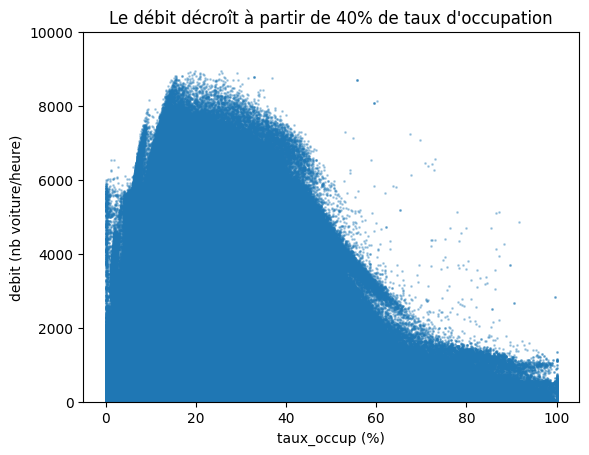

Cela correspond à un traffic chargé : les voitures avancent peu donc le débit est faible mais elles occupent la zone donc le taux d'occupation est élevé
Le débit est également plus faible en dessous de 10% de taux d'occupation : cela correspond à trafic faible où il y a peu de voitures qui passent (débit faible) et qui n'occupent que peu la zone (taux d'occupation faible)
Corrélation = 0.396


In [67]:
corr = trafic_df["taux_occup"].corr(trafic_df["debit"])
x = trafic_df["taux_occup"]
y = trafic_df["debit"]

plt.scatter(x, y, s=1, alpha=0.3)

plt.ylim(0, 10000)

plt.xlabel("taux_occup (%)")
plt.ylabel("debit (nb voiture/heure)")
plt.title("Le débit décroît à partir de 40% de taux d'occupation")

plt.show()
print("Cela correspond à un traffic chargé : les voitures avancent peu donc le débit est faible mais elles occupent la zone donc le taux d'occupation est élevé")
print("Le débit est également plus faible en dessous de 10% de taux d'occupation : cela correspond à trafic faible où il y a peu de voitures qui passent (débit faible) et qui n'occupent que peu la zone (taux d'occupation faible)")
print(f"Corrélation = {corr:.3f}")

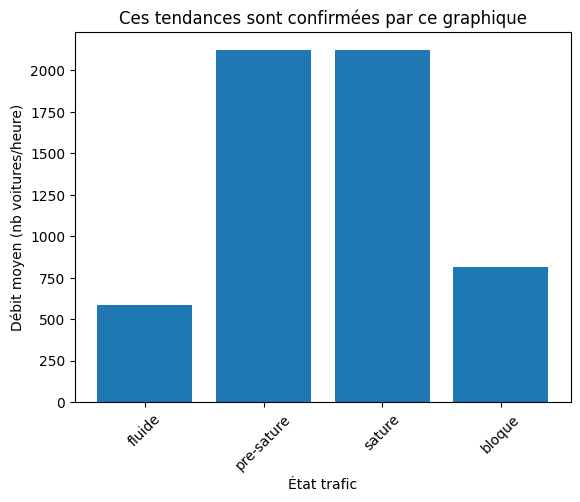

Pour rappel, l'état du trafic est calculé en fonction du taux d'occupation


In [68]:
avg_debit_by_etat_trafic = trafic_df.groupby("etat_trafic_encode")["debit"].mean()
labels = avg_debit_by_etat_trafic.index.map(mapping_etat_trafic)

plt.figure()
plt.bar(labels, avg_debit_by_etat_trafic.values)
plt.xlabel("État trafic")
plt.ylabel("Débit moyen (nb voitures/heure)")
plt.title("Ces tendances sont confirmées par ce graphique")
plt.xticks(rotation=45)
plt.show()
print("Pour rappel, l'état du trafic est calculé en fonction du taux d'occupation")

## Débit / Taux d'occupation / état du trafic X état d'ouverture de la voie

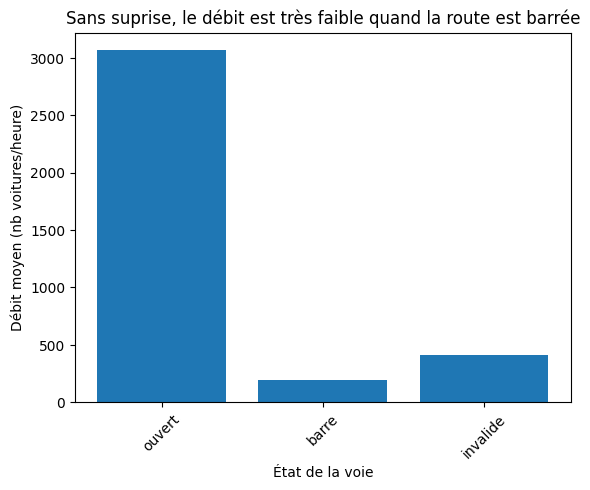

Nombre d'observations par bars :
etat_barre_encode
invalide    27040892
ouvert       4092149
barre         710688
Name: count, dtype: int64
Je ne comprends pas bien ce que etat_barre = invalide


In [69]:
avg_debit_by_etat_barre = trafic_df.groupby("etat_barre_encode")["debit"].mean()
labels = avg_debit_by_etat_barre.index.map(mapping_etat_barre)
nb_obs_by_bars_debit_x_barre = trafic_df["etat_barre_encode"].value_counts()
nb_obs_by_bars_debit_x_barre.index = nb_obs_by_bars_debit_x_barre.index.map(mapping_etat_barre)

plt.figure()
plt.bar(labels, avg_debit_by_etat_barre.values)
plt.xlabel("État de la voie")
plt.ylabel("Débit moyen (nb voitures/heure)")
plt.title("Sans suprise, le débit est très faible quand la route est barrée")
plt.xticks(rotation=45)
plt.show()
print("Nombre d'observations par bars :")
print(nb_obs_by_bars_debit_x_barre)
print("Je ne comprends pas bien ce que etat_barre = invalide")

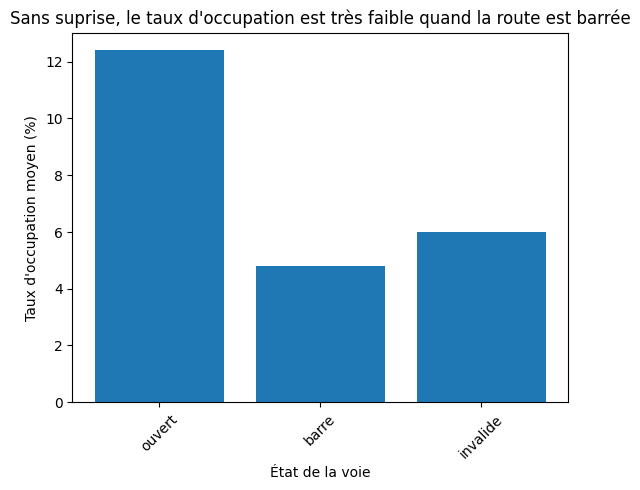

In [70]:
avg_taux_occup_by_etat_barre = trafic_df.groupby("etat_barre_encode")["taux_occup"].mean()
labels = avg_taux_occup_by_etat_barre.index.map(mapping_etat_barre)

plt.figure()
plt.bar(labels, avg_taux_occup_by_etat_barre.values)
plt.xlabel("État de la voie")
plt.ylabel("Taux d'occupation moyen (%)")
plt.title("Sans suprise, le taux d'occupation est très faible quand la route est barrée")
plt.xticks(rotation=45)
plt.show()

# Evolution Temporelle

## Identification d'une semaine "type"

Pour résumer cette section, le trafic à Paris est plus dense la semaine (débit moyen > 700 véhicules/heure et taux d'occupation moyen > 6%) que le week-end (débit moyen entre 600 et 700 véhicules par heure et taux d'occupation moyen entre 5 et 6%).

Cette tendance s'explique probablement par les trajets professionnels, plus présents en semaine

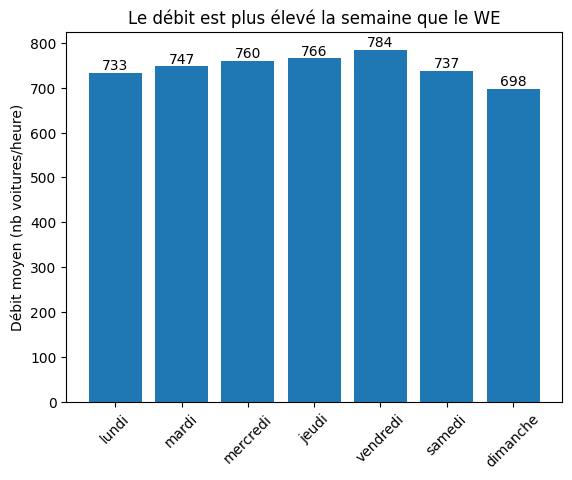

In [71]:
avg_debit_par_jour_semaine = trafic_df.groupby(trafic_df["date_fin"].dt.dayofweek)["debit"].mean()
mapping_jour_semaine = {
    0: "lundi",
    1: "mardi",
    2: "mercredi",
    3: "jeudi",
    4: "vendredi",
    5: "samedi",
    6: "dimanche"
}
labels = avg_debit_par_jour_semaine.index.map(mapping_jour_semaine)

fig, ax = plt.subplots()
bars = ax.bar(labels, avg_debit_par_jour_semaine.values)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.0f}',
        ha='center',
        va='bottom'
    )

ax.set_ylabel("Débit moyen (nb voitures/heure)")
ax.set_title("Le débit est plus élevé la semaine que le WE")
plt.xticks(rotation=45)
plt.show()

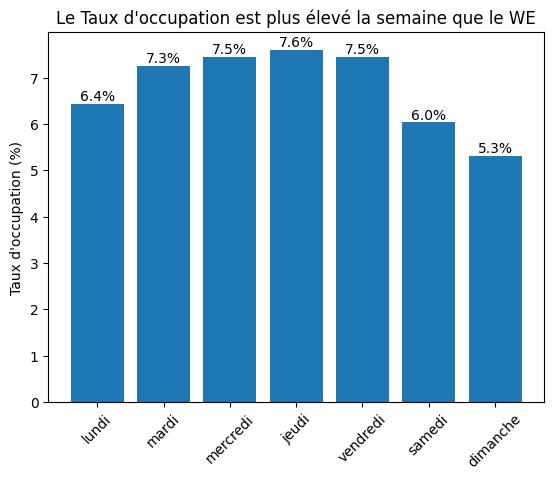

In [74]:
avg_occup_par_jour_semaine = trafic_df.groupby(trafic_df["date_fin"].dt.dayofweek)["taux_occup"].mean()
mapping_jour_semaine = {
    0: "lundi",
    1: "mardi",
    2: "mercredi",
    3: "jeudi",
    4: "vendredi",
    5: "samedi",
    6: "dimanche"
}
labels = avg_occup_par_jour_semaine.index.map(mapping_jour_semaine)

fig, ax = plt.subplots()
bars = ax.bar(labels, avg_occup_par_jour_semaine.values)

for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f'{height:.1f}%',
        ha='center',
        va='bottom'
    )

ax.set_ylabel("Taux d'occupation (%)")
ax.set_title("Le Taux d'occupation est plus élevé la semaine que le WE")
plt.xticks(rotation=45)
plt.show()

## Identification d'une journée type (semaine VS WE)

Pour résumer cette section, le trafic à Paris est plus dense, que cela soit en terme de débit ou de taux d'occupation : 
- La semaine entre 9h et 20h
- Le week-end entre 13h et 20h

Cette tendance peut également s'expliquer par les trajets professionnels (trajets plus tôt le matin)

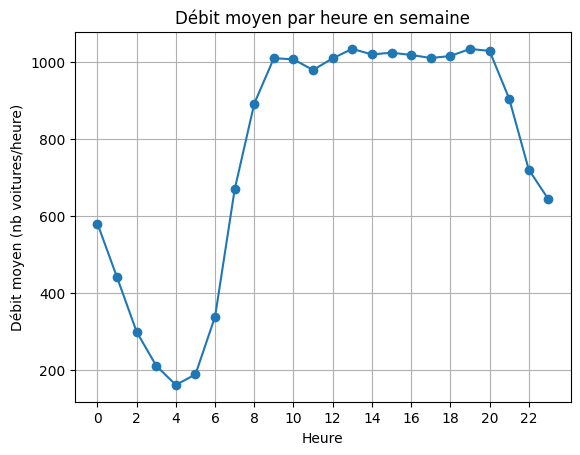

In [75]:
avg_debit_semaine = trafic_df.loc[trafic_df["date_fin"].dt.dayofweek < 5] \
    .groupby(trafic_df.loc[trafic_df["date_fin"].dt.dayofweek < 5, "date_fin"].dt.hour)["debit"] \
    .mean()

plt.figure()
plt.plot(avg_debit_semaine.index, avg_debit_semaine.values, marker="o")
plt.xlabel("Heure")
ticks = range(0, 24, 2)
plt.xticks(ticks)
plt.ylabel("Débit moyen (nb voitures/heure)")
plt.title("Débit moyen par heure en semaine")
plt.grid(True)
plt.show()

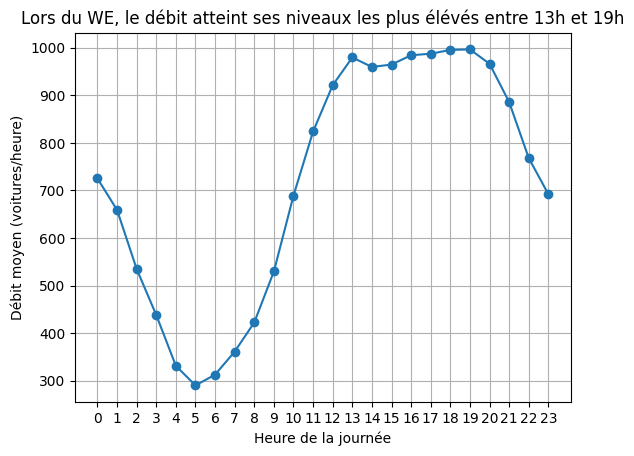

In [76]:
avg_debit_weekend = trafic_df.loc[trafic_df["date_fin"].dt.dayofweek >= 5] \
    .groupby(trafic_df.loc[trafic_df["date_fin"].dt.dayofweek >= 5, "date_fin"].dt.hour)["debit"] \
    .mean()

plt.figure()
plt.plot(avg_debit_weekend.index, avg_debit_weekend.values, marker="o")
plt.xlabel("Heure de la journée")
plt.ylabel("Débit moyen (voitures/heure)")
plt.title("Lors du WE, le débit atteint ses niveaux les plus élévés entre 13h et 19h")
plt.xticks(range(24))
plt.grid(True)
plt.show()

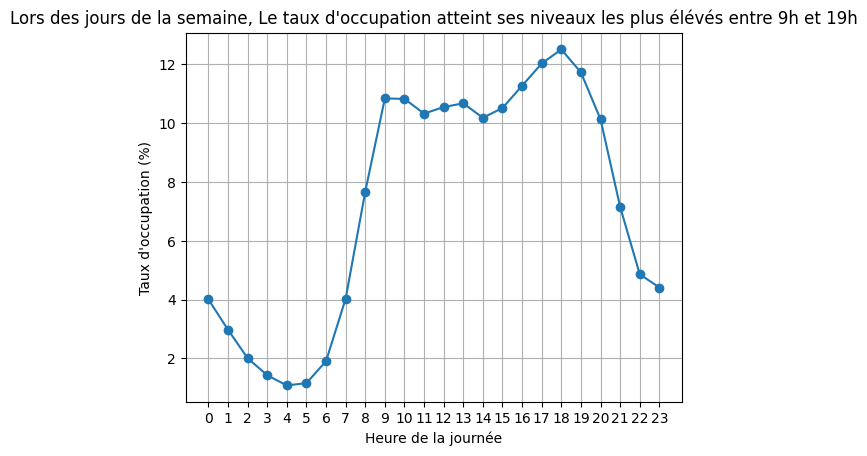

In [77]:
avg_taux_semaine = trafic_df.loc[trafic_df["date_fin"].dt.dayofweek < 5] \
    .groupby(trafic_df.loc[trafic_df["date_fin"].dt.dayofweek < 5, "date_fin"].dt.hour)["taux_occup"] \
    .mean()

plt.figure()
plt.plot(avg_taux_semaine.index, avg_taux_semaine.values, marker="o")
plt.xlabel("Heure de la journée")
plt.ylabel("Taux d'occupation (%)")
plt.title("Lors des jours de la semaine, Le taux d'occupation atteint ses niveaux les plus élévés entre 9h et 19h")
plt.xticks(range(24))
plt.grid(True)
plt.show()

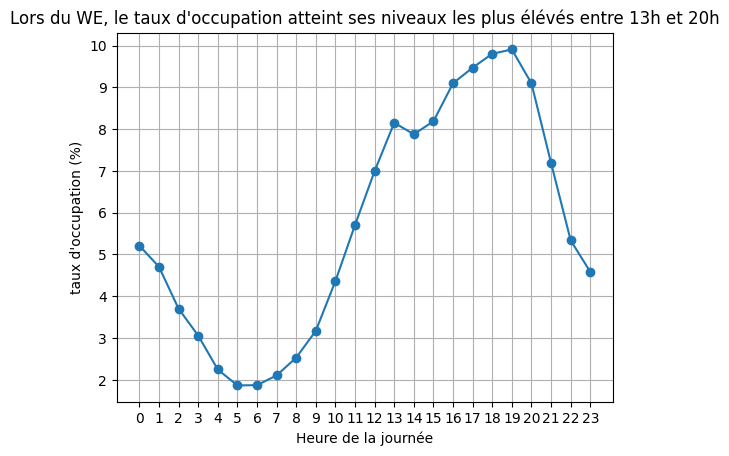

In [78]:
avg_taux_weekend = trafic_df.loc[trafic_df["date_fin"].dt.dayofweek >= 5] \
    .groupby(trafic_df.loc[trafic_df["date_fin"].dt.dayofweek >= 5, "date_fin"].dt.hour)["taux_occup"] \
    .mean()


plt.figure()
plt.plot(avg_taux_weekend.index, avg_taux_weekend.values, marker="o")
plt.xlabel("Heure de la journée")
plt.ylabel("taux d'occupation (%)")
plt.title("Lors du WE, le taux d'occupation atteint ses niveaux les plus élévés entre 13h et 20h")
plt.xticks(range(24))
plt.grid(True)
plt.show()

## Tendance du trafic général entre 2021 et 2023

Pour résumer cette section, on constate que le trafic suit une tendance à la hausse entre 2021 et 2023 à Paris. Les débits et taux d'occupation moyen augmentent entre 2021 et 2023.

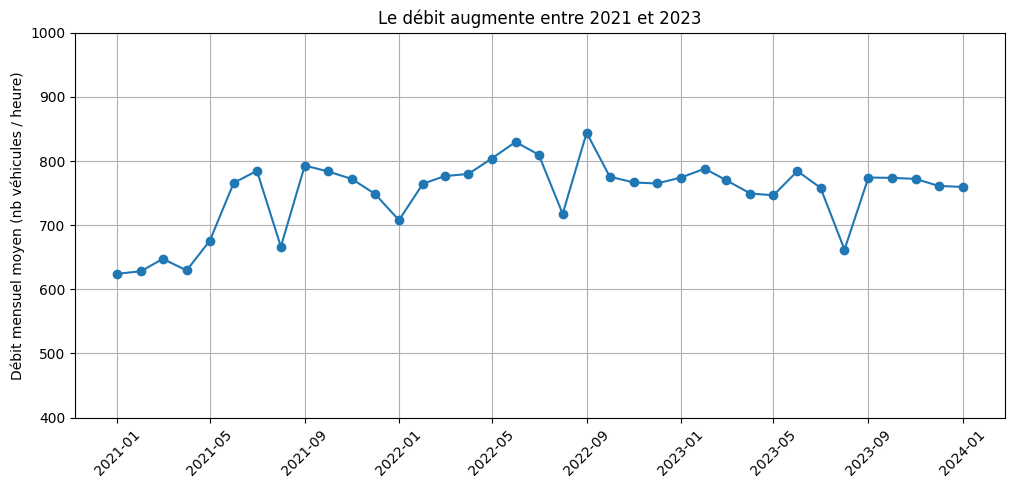

In [79]:
monthly_avg = trafic_df.groupby(
    [trafic_df["date_fin"].dt.year, trafic_df["date_fin"].dt.month]
)["debit"].mean()

monthly_avg.index = pd.to_datetime([f"{y}-{m:02d}-01" for y, m in monthly_avg.index])

plt.figure(figsize=(12,5))
plt.plot(monthly_avg.index, monthly_avg.values, marker='o', linestyle='-')
plt.ylabel("Débit mensuel moyen (nb véhicules / heure)")
plt.ylim(400, 1000)
plt.title("Le débit augmente entre 2021 et 2023")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

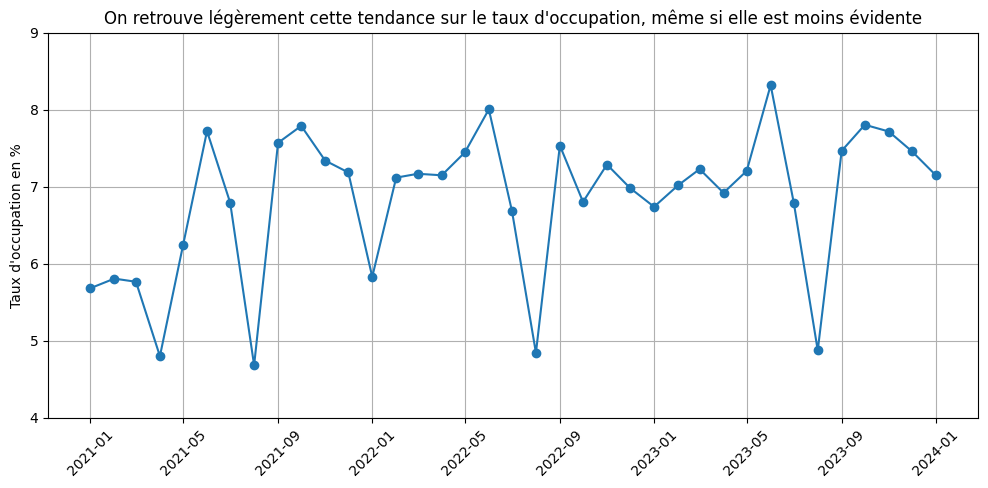

In [80]:
monthly_avg_occup = trafic_df.groupby(
    [trafic_df["date_fin"].dt.year, trafic_df["date_fin"].dt.month]
)["taux_occup"].mean()

monthly_avg_occup.index = pd.to_datetime([f"{y}-{m:02d}-01" for y, m in monthly_avg_occup.index])

plt.figure(figsize=(12,5))
plt.plot(monthly_avg_occup.index, monthly_avg_occup.values, marker='o', linestyle='-')
plt.ylabel("Taux d'occupation en %")
plt.ylim(4, 9)
plt.title("On retrouve légèrement cette tendance sur le taux d'occupation, même si elle est moins évidente")
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

## Evolution en fonction des mois

Pour résumer cette section, le trafic suit une certaine saisonalité mensuelle : 
- Il est plutôt bas en début d'année, avec un débit moyen de 700 à 720 véhicules par heure et un taux d'occupation moyen entre 6 et 6.6% entre janvier et avril. Cette tendance est difficile à expliquer
- Il augmente ensuite pour atteindre un pic en juin de 790 véhicules par heure en moyenne et 8% de taux d'occupation moyen. Ce pic est aussi difficile à expliquer
- Suite à ça, il décroîr fortement pour atteindre son niveau le plus bas en août (680 de débit moyen, 4.7% de taux d'occupation). Cela pourrait s'expliquer par les vacances des Parisiens en août
- Il remonte enfin en septembre pour rester à un niveau plutôt élevé jusqu'en décembre. Cette tendance est également difficile à expliquer

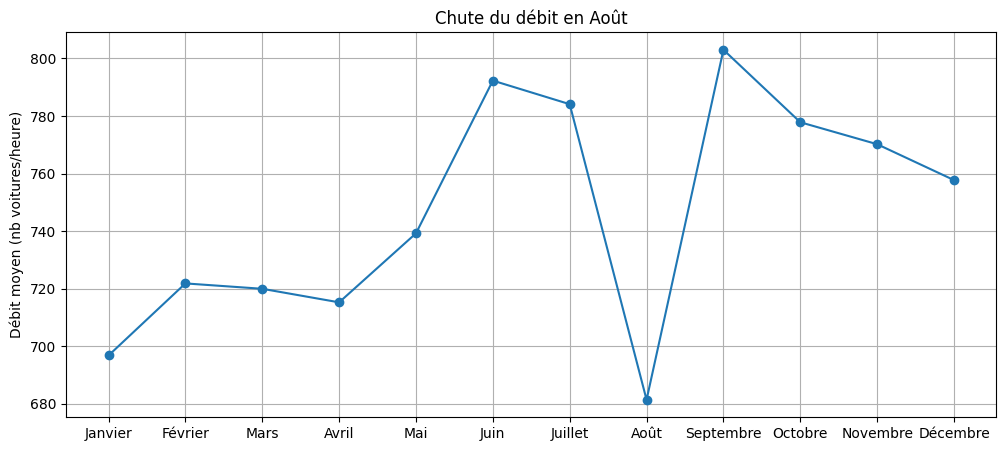

on oonstate également que le débit est plus faible en début d'année (janvier à avril) et plus élevé en fin d'année (Septembre à décembre)


In [81]:
monthly_avg = trafic_df.groupby(trafic_df["date_fin"].dt.month)["debit"].mean()

month_names = ["Janvier","Février","Mars","Avril","Mai","Juin",
               "Juillet","Août","Septembre","Octobre","Novembre","Décembre"]
labels = [month_names[m-1] for m in monthly_avg.index]

plt.figure(figsize=(12,5))
plt.plot(labels, monthly_avg.values, marker='o', linestyle='-')
plt.ylabel("Débit moyen (nb voitures/heure)")
plt.title("Chute du débit en Août")
plt.grid(True)
plt.show()
print("on oonstate également que le débit est plus faible en début d'année (janvier à avril) et plus élevé en fin d'année (Septembre à décembre)")

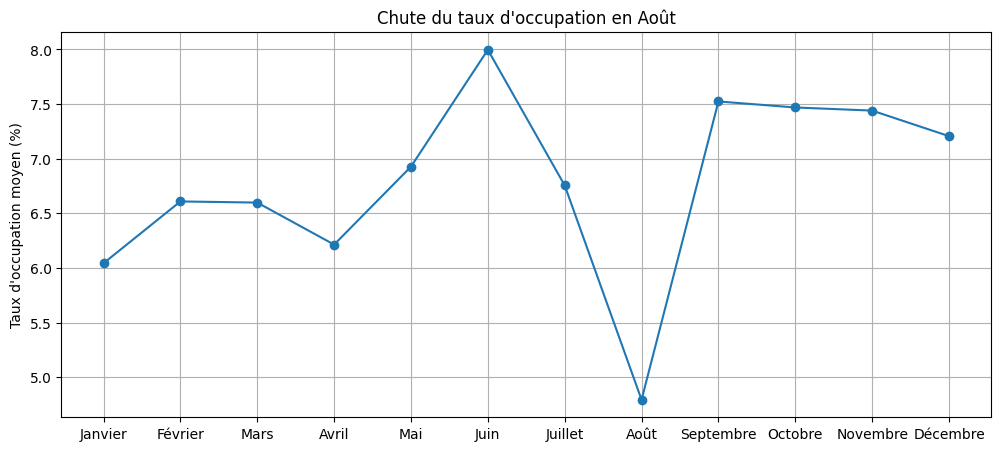

on oonstate également que le taux d'occupation est plus faible en début d'année (janvier à avril) et plus élevé en fin d'année (Septembre à décembre)


In [82]:
monthly_avg = trafic_df.groupby(trafic_df["date_fin"].dt.month)["taux_occup"].mean()

month_names = ["Janvier","Février","Mars","Avril","Mai","Juin",
               "Juillet","Août","Septembre","Octobre","Novembre","Décembre"]
labels = [month_names[m-1] for m in monthly_avg.index]

plt.figure(figsize=(12,5))
plt.plot(labels, monthly_avg.values, marker='o', linestyle='-')
plt.ylabel("Taux d'occupation moyen (%)")
plt.title("Chute du taux d'occupation en Août")
plt.grid(True)
plt.show()
print("on oonstate également que le taux d'occupation est plus faible en début d'année (janvier à avril) et plus élevé en fin d'année (Septembre à décembre)")